# Section 1: Environment Setup & Dependency Installation

In [ ]:
# ==============================================================================
# Environment Dependency Specification
# Socratic Dialectical Refinement (SDR) Notebook Runtime Setup
# ==============================================================================

# Install all necessary runtime packages for:
# 1. State Machine Orchestration: langgraph, langchain, grandalf
# 2. Local Model Inference: ollama, langchain-ollama, torch, transformers, langchain_huggingface
# 3. Dataset Ingestion & Processing: datasets, pandas, pyarrow
# 4. Telemetry & Observability: arize-phoenix, arize-phoenix-evals, openinference-instrumentation-langchain, arize-phoenix-client

# !pip install -qU ollama langchain-ollama torch transformers datasets langchain langchain_huggingface grandalf langgraph arize-phoenix arize-phoenix-evals pandas pyarrow openinference-instrumentation-langchain arize-phoenix-client -q

In [1]:
import warnings
from langchain_core._api import LangChainDeprecationWarning

# Suppress only LangChain deprecation warnings
warnings.filterwarnings("ignore", category=LangChainDeprecationWarning)

## Section 1.1: Local SLM Serving Engine Provisioning (Ollama)

In [2]:
# ==============================================================================
# Ollama Local Runtime Engine Deployment
# Purpose: Fetch and install the Ollama binary for local, open-source SLM execution
# ==============================================================================

# Execute installation script
# -fsSL flags:
#   -f: Fail silently on server errors (HTTP 4xx/5xx)
#   -s: Silent/quiet mode (suppress progress meters)
#   -S: Show error message if transfer fails
#   -L: Follow HTTP redirects to the final script source
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%                             57.0%
>>> Adding ollama user to render group...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> Enabling and starting ollama service...
>>> NVIDIA GPU installed.


## Section 1.2: Local SLM Initialization & Model Provisioning

In [64]:
# ==============================================================================
# SLM Lifecycle Management and Model Suite Pull
# Purpose: Start the background Ollama server, pull the target Qwen 2.5 SLM family
#          (0.5B, 1.5B, 3B, 7B), and verify local model inventory metadata.
# ==============================================================================

import json
import os
import subprocess
import ollama

# ------------------------------------------------------------------------------
# 1. Background Inference Engine Daemon Launch
# ------------------------------------------------------------------------------
# Spawns 'ollama serve' as an independent daemon to handle local REST/gRPC API requests.
# DEVNULL redirection ensures execution logs do not pollute notebook cell outputs.
ollama_process = subprocess.Popen(
    ['ollama', 'serve'], 
    stdout=subprocess.DEVNULL, 
    stderr=subprocess.DEVNULL
)

# ------------------------------------------------------------------------------
# 2. Sequential Acquisition of Target Evaluation Models
# ------------------------------------------------------------------------------
# Fetch off-the-shelf instruction-tuned Qwen 2.5 checkpoints - 1.5B, 3B and 7B.
# These checkpoints serve as the empirical testbed across DA, CoT, and SDR conditions.
ollama.pull('qwen2.5:0.5b-instruct')
ollama.pull('qwen2.5:1.5b-instruct')
ollama.pull('qwen2.5:3b-instruct')
ollama.pull('qwen2.5:7b-instruct')

# ------------------------------------------------------------------------------
# 3. Model Inventory and Metadata Verification
# ------------------------------------------------------------------------------
# Query the local Ollama daemon for available model manifests.
response = ollama.list()

# Standard conversion of the Pydantic response object to a native dictionary
data_dict = response.model_dump()

# Print detailed model specifications (family, parameter size, quantization format)
for model in data_dict['models']:
    for key, value in model.items():
        if key == 'details' and isinstance(value, dict):
            print("details:")
            for sub_key, sub_value in value.items():
                print(f"         {sub_key}: {sub_value}")
        else:
            print(f"{key}: {value}")
    print("\n")

model: qwen2.5:7b-instruct
modified_at: 2026-08-30 06:58:10.484621+00:00
digest: 845dbda0ea48ed749caafd9e6037047aa19acfcfd82e704d7ca97d631a0b697e
size: 4683087332
details:
         parent_model: 
         format: gguf
         family: qwen2
         families: ['qwen2']
         parameter_size: 7.6B
         quantization_level: Q4_K_M


model: qwen2.5:3b-instruct
modified_at: 2026-08-30 06:57:44.155053+00:00
digest: 357c53fb659c5076de1d65ccb0b397446227b71a42be9d1603d46168015c9e4b
size: 1929912432
details:
         parent_model: 
         format: gguf
         family: qwen2
         families: ['qwen2']
         parameter_size: 3.1B
         quantization_level: Q4_K_M


model: qwen2.5:1.5b-instruct
modified_at: 2026-08-30 06:57:43.820020+00:00
digest: 65ec06548149b04c096a120e4a6da9d4017ea809c91734ea5631e89f96ddc57b
size: 986061892
details:
         parent_model: 
         format: gguf
         family: qwen2
         families: ['qwen2']
         parameter_size: 1.5B
         quantization_l

## Section 1.3: Observability Instrumentation and OpenTelemetry Telemetry Setup

In [4]:
# ==============================================================================
# Observability and Tracing Engine Initialization (Arize Phoenix)
# Purpose: Configure OpenTelemetry instrumentation for LangChain/LangGraph,
#          setting up trace collection for computational cost (token) analysis.
# ==============================================================================

import warnings
# Suppress the specific non-serializable default warning from Pydantic
warnings.filterwarnings("ignore", message=".*non-serializable-default.*")

import os
import time
import phoenix as px
from openinference.instrumentation.langchain import LangChainInstrumentor
from phoenix.client import Client
from phoenix.otel import register

# ------------------------------------------------------------------------------
# 1. OpenTelemetry (OTEL) Trace Registration
# ------------------------------------------------------------------------------
# Register the Phoenix OpenTelemetry tracer provider to capture execution graphs
tracer_provider = register()

# Auto-instrument LangChain/LangGraph execution pipelines to log node spans,
# sub-question latencies, and token counts for intermediate refinement steps
LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

# ------------------------------------------------------------------------------
# 2. Storage Directory Configuration for Telemetry Persistence
# ------------------------------------------------------------------------------
# Configure working directory path depending on the host compute environment:
# os.environ["PHOENIX_WORKING_DIR"] = "/content"      # Google Colab environment
os.environ["PHOENIX_WORKING_DIR"] = "Phoenix"         # Lightning.ai / Local environment

# ------------------------------------------------------------------------------
# 3. Phoenix UI & Observability Server Deployment
# ------------------------------------------------------------------------------
# Launch the persistent Phoenix application instance for real-time trace inspection
session = px.launch_app(use_temp_dir=False)

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: default
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



E0830 10:08:25.847194   10390 add_port.cc:83] Failed to add port to server: No address added out of total 1 resolved for '[::]:4317' (Failed to add any wildcard listeners: Error in bind for address '[::]:4317': Address already in useError in bind for address '0.0.0.0:4317': Address already in use)
ERROR:    Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/starlette/routing.py", line 638, in lifespan
    async with self.lifespan_context(app) as maybe_state:
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/contextlib.py", line 210, in __aenter__
    return await anext(self.gen)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/fastapi/routing.py", line 232, in merged_lifespan
    async with original_context(app) as maybe_original_state:
               ^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace

🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
💽 Your data is being persisted to sqlite:////teamspace/studios/this_studio/Phoenix/phoenix.db
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix


In [5]:
# # Display the dashboard inline
# session

# Section 2: Framework Module Ingestion & Orchestration Imports

In [6]:
# ==============================================================================
# Core Framework Module Ingestion and Runtime Bindings
# Purpose: Import core graph engines, prompting abstractions, parsing utilities,
#          and type definitions for the SDR state machine and baselines (DA, CoT).
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. System, Type Hints, and Structural Data Modeling
# ------------------------------------------------------------------------------
import os
from typing import Dict, List, TypedDict, Literal, Optional, Union
from pydantic import BaseModel, Field
import pandas as pd

# ------------------------------------------------------------------------------
# 2. Graph State Machine Orchestration (LangGraph Engine)
# ------------------------------------------------------------------------------
from langgraph.graph import StateGraph, END

# ------------------------------------------------------------------------------
# 3. Model Connectors and In-Memory Serving (Ollama & Hugging Face Backends)
# ------------------------------------------------------------------------------
from langchain_ollama import ChatOllama
# from langchain_openai import ChatOpenAI
from langchain_huggingface import ChatHuggingFace
from langchain_huggingface.llms import HuggingFacePipeline

# ------------------------------------------------------------------------------
# 4. Prompt Engineering Abstractions and Structured Output Parsers
# ------------------------------------------------------------------------------
from langchain_core.prompts import (
    ChatPromptTemplate, 
    SystemMessagePromptTemplate, 
    HumanMessagePromptTemplate, 
    AIMessagePromptTemplate
)
from langchain_core.output_parsers import StrOutputParser, XMLOutputParser

# ------------------------------------------------------------------------------
# 5. Scientific Computing, Regular Expressions, and Benchmark Ingestion
# ------------------------------------------------------------------------------
import re
import requests
import torch
from datasets import load_dataset
from transformers import GenerationConfig
# from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM

# ------------------------------------------------------------------------------
# 6. Pipeline Imports (Preserved for Codebase Execution Integrity)
# ------------------------------------------------------------------------------
import os
from typing import Dict, List, TypedDict, Literal, Optional
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
# from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langchain_ollama import ChatOllama

import re

from typing import Union
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field

import requests
import re
import torch
from datasets import load_dataset
# from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
from langchain_huggingface.llms import HuggingFacePipeline
from langchain_core.prompts import (
    ChatPromptTemplate, 
    SystemMessagePromptTemplate, 
    HumanMessagePromptTemplate, 
    AIMessagePromptTemplate
)
from langchain_core.output_parsers import StrOutputParser
from transformers import GenerationConfig
from langchain_huggingface import ChatHuggingFace
from transformers import GenerationConfig
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import XMLOutputParser

import os
from typing import Dict, List, TypedDict, Literal, Optional
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
# from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langchain_ollama import ChatOllama

In [7]:
#session.view()

#session.end()

# http://localhost:11434/v1/

# Section 3: GSM8K Test Dataset Ingestion and Ground Truth Cleansing

In [8]:
# ==============================================================================
# GSM8K Ingestion, Numeric Cleansing, and Phoenix Experiment Binding
# Purpose: Ingest GSM8K test split, isolate ground-truth numeric answers from
#          full reasoning traces, and register the dataset schema in Arize Phoenix.
# ==============================================================================

import re
from datasets import load_dataset
from phoenix.client import Client

# ------------------------------------------------------------------------------
# 1. Ground Truth Canonicalization Function
# ------------------------------------------------------------------------------
def extract_numeric_answer(text):
    """
    Extracts the canonical numeric ground truth from the GSM8K natural language solution.
    
    GSM8K annotates final target values at the conclusion of rationale chains
    preceded by '####'. This function parses integer and floating-point values
    (including negative quantities) for deterministic Exact Match (EM) evaluation.
    """
    match = re.search(r'#### (-?\d+\.?\d*)', text)
    if match:
        return match.group(1)
    return None

# ------------------------------------------------------------------------------
# 2. Benchmark Ingestion & DataFrame Transformation
# ------------------------------------------------------------------------------
# Load the official test partition of the GSM8K benchmark from Hugging Face Hub
gsm8k_dataset = load_dataset('openai/gsm8k', 'main', split='test')

# Convert the Dataset object to a structured pandas DataFrame
gsm8k_df = gsm8k_dataset.to_pandas()

# print(f'Loaded {len(gsm8k_df)} examples from the GSM8K test split.')
# print('Displaying the first 5 rows:')
# display(gsm8k_df.head())

# Preserve original step-by-step chain-of-thought rationale as 'trace'
gsm8k_df['trace'] = gsm8k_df['answer']

# Standardize the 'answer' column to contain strictly the final target scalar
gsm8k_df['answer'] = gsm8k_df['answer'].apply(extract_numeric_answer)

print("DataFrame after extracting numeric answer and renaming columns:")
display(gsm8k_df.head())

# ------------------------------------------------------------------------------
# 3. Observability Dataset Schema Registration (Phoenix Platform)
# ------------------------------------------------------------------------------
# Instantiate the local Phoenix client
client = Client()

# Persist the evaluation dataset into Phoenix for evaluation tracking
dataset = client.datasets.create_dataset(
    dataframe=gsm8k_df[:300],   ###### create experiment dataset with 300 questions from GSM8K test set
    name="gsm8k_main_test",
    input_keys=["question"],
    output_keys=["answer"],
    metadata_keys={"trace"}
)

# Section 4: Model Engine Instantiation & Hyperparameter Standardization

In [55]:
# ==============================================================================
# Local SLM Instance Initialization & Experimental Condition Binding
# Purpose: Configure deterministic ChatOllama instances for Direct Answer (DA),
#          Chain of Thought (CoT), and Socratic Dialectical Refinement (SDR).
# ==============================================================================

from langchain_ollama import ChatOllama

# ------------------------------------------------------------------------------
# 1. Set Evaluation Models
# ------------------------------------------------------------------------------

slm_qwen25_0_5_B = ChatOllama(
    model="qwen2.5:0.5b-instruct",
    base_url="http://localhost:11434",
    temperature=0,
    num_ctx=4096,       # Total context window (prompt + response)
    num_predict=1024,    # Max output tokens to generate
    reasoning=False
)

slm_qwen25_1_5_B = ChatOllama(
    model="qwen2.5:1.5b-instruct",
    base_url="http://localhost:11434",
    temperature=0,
    num_ctx=4096,       # Total context window (prompt + response)
    num_predict=1024,    # Max output tokens to generate
    reasoning=False
)

slm_qwen25_3_B = ChatOllama(
    model="qwen2.5:3b-instruct",
    base_url="http://localhost:11434",
    temperature=0,
    num_ctx=4096,       # Total context window (prompt + response)
    num_predict=1024,    # Max output tokens to generate
    reasoning=False
)

slm_qwen25_7_B = ChatOllama(
    model="qwen2.5:7b-instruct",
    base_url="http://localhost:11434",
    temperature=0,
    num_ctx=4096,       # Total context window (prompt + response)
    num_predict=1024,    # Max output tokens to generate
    reasoning=False
)

# Section 5: Baseline Implementation — Direct Answer (DA) Paradigm

In [10]:
# ==============================================================================
# Direct Answer (DA) Baseline Chain and Execution Task
# Purpose: Implement zero-rationale direct answering using structured Pydantic
#          outputs for deterministic Exact Match (EM) evaluation.
# ==============================================================================

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# ------------------------------------------------------------------------------
# 1. Pydantic Structured Output Schema Definition
# ------------------------------------------------------------------------------
class DirectAnswerResponse(BaseModel):
    """
    Schema definition enforcing strict numeric isolation on model generations.
    Guarantees output parsing conformant with canonical benchmark targets.
    """
    final_answer: int = Field(
        description="The raw derived final numerical value answering the word problem. "
                    "Digits and optional decimal point ONLY (e.g. '16', '1250', '18.9'). "
                    "No symbols, units, or text."
    )

# ------------------------------------------------------------------------------
# 2. Prompt Engineering: Direct Input/Output with Exemplars
# ------------------------------------------------------------------------------
# Direct Answer system prompt constraining generation to scalar output
DA_SYSTEM_PROMPT = """You are an ultra-precise mathematical word problem solver. Your sole task is to calculate the final numerical answer to the word problem and output it in the structured format.

STRICT FORMAT RULES FOR `final_answer`:
- Output strictly the raw numerical value (e.g., 50, 1250, 14.5).
- DO NOT include currency symbols ($), commas (,), units (apples, miles), percentages (%), or introductory text ("The answer is").
- DO NOT include trailing decimal zeros (write 18, not 18.0).
- Simplify fractions to decimals or integers.

FEW-SHOT example 1:
Word Problem: A store sells apples in bags of 6. If John buys 3 bags and eats 2 apples, how many does he have left?
Output: {{"final_answer": 16}}

FEW-SHOT example 2:
Word Problem: A book costs $20 and is on sale for 10% off. What is the sale price?
Output: {{"final_answer": 18}}"""

# User prompt template binding the incoming GSM8K problem statement
DA_USER_PROMPT = """Word Problem: {question}"""

# ------------------------------------------------------------------------------
# 4. Factory Construction for DA Baseline Execution
# ------------------------------------------------------------------------------

def create_da_task(slm):
    # Compile into a structured LangChain ChatPromptTemplate
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", DA_SYSTEM_PROMPT),
            ("user", DA_USER_PROMPT),
        ]
    )
    
    # Bind Pydantic response schema to the DA model instance
    structured_slm = slm.with_structured_output(DirectAnswerResponse)
    
    # Construct LCEL pipeline linking prompt template with structured model
    structured_da_chain = prompt | structured_slm
    
    # ------------------------------------------------------------------------------
    # Standardized Dataset Evaluation Task Interface
    # ------------------------------------------------------------------------------
    def da_task(problem: dict) -> dict:
        """Invokes the DA chain on a GSM8K problem and cleans the result for Exact Match evaluation."""
            
        response: DirectAnswerResponse = structured_da_chain.invoke(
            {"question": problem["question"]}
        )
        
        return {
            "gen_answer": str(response.final_answer),
        }
    
    return da_task

# Section 6: Baseline Implementation — Few-Shot Chain-of-Thought (CoT) Paradigm

In [13]:
# ==============================================================================
# Few-Shot Chain-of-Thought (CoT) Baseline Specification and Task Factory
# Purpose: Implement 8-shot standard CoT prompting via structured Pydantic schemas
#          to evaluate baseline SLM multi-step reasoning performance on GSM8K.
# ==============================================================================

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# ------------------------------------------------------------------------------
# 1. Pydantic Structured Output Schema Definition
# ------------------------------------------------------------------------------
class CoTResponse(BaseModel):
    """
    Schema separating intermediate natural language rationales from the final scalar.
    Enforces clean parsing of step-by-step logic and the target numerical output.
    """
    reasoning: str = Field(
        description="Step-by-step mathematical reasoning and plan."
    )
    final_answer: int = Field(
        description="The raw derived final numerical value answering the word problem. "
                    "Digits and optional decimal point ONLY (e.g. '16', '1250', '18.9'). "
                    "No symbols, units, or text."
    )

# ------------------------------------------------------------------------------
# 2. Few-Shot In-Context Exemplars (Standard 8-Shot GSM8K Demonstrations)
# ------------------------------------------------------------------------------
# In-context exemplars formatted with escaped JSON braces for LangChain LCEL parsing.
COT_SYSTEM_PROMPT = """
Example 1:
Input: Question: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there will be 21 trees. How many trees did the grove workers plant today?
Output:
{{
"reasoning": "There are 15 trees originally. Then there were 21 trees after some more were planted. So there must have been 21 - 15 = 6.",
"final_answer": 6
}}

Example 2:
Input: Question: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?
Output:
{{
"reasoning": "There are originally 3 cars. 2 more cars arrive. 3 + 2 = 5.",
"final_answer": 5
}}

Example 3:
Input: Question: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?
Output:
{{
"reasoning": "Originally, Leah had 32 chocolates. Her sister had 42. So in total they had 32 + 42 = 74. After eating 35, they had 74 - 35 = 39.",
"final_answer": 39
}}

Example 4:
Input: Question: Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. How many lollipops did Jason give to Denny?
Output:
{{
"reasoning": "Jason started with 20 lollipops. Then he had 12 after giving some to Denny. So he gave Denny 20 - 12 = 8.",
"final_answer": 8
}}

Example 5:
Input: Question: Shawn has five toys. For Christmas, he got two toys each from his mom and dad. How many toys does he have now?
Output:
{{
"reasoning": "Shawn started with 5 toys. If he got 2 toys each from his mom and dad, then that is 4 more toys. 5 + 4 = 9.",
"final_answer": 9
}}

Example 6:
Input: Question: There were nine computers in the server room. Five more computers were installed each day, from monday to thursday. How many computers are now in the server room?
Output:
{{
"reasoning": "There were originally 9 computers. For each of 4 days, 5 more computers were added. So 5 * 4 = 20 computers were added. 9 + 20 is 29.",
"final_answer": 29
}}

Example 7:
Input: Question: Michael had 58 golf balls. On tuesday, he lost 23 golf balls. On wednesday, he lost 2 more. How many golf balls did he have at the end of wednesday?
Output:
{{
"reasoning": "Michael started with 58 golf balls. After losing 23 on tuesday, he had 58 - 23 = 35. After losing 2 more, he had 35 - 2 = 33 golf balls.",
"final_answer": 33
}}

Example 8:
Input: Question: Olivia has $23. She bought five bagels for $3 each. How much money does she have left?
Output:
{{
"reasoning": "Olivia had 23 dollars. 5 bagels for 3 dollars each will be 5 x 3 = 15 dollars. So she has 23 - 15 dollars left. 23 - 15 is 8.",
"final_answer": 8
}}
"""

# ------------------------------------------------------------------------------
# 3. User Input Binding Template
# ------------------------------------------------------------------------------
COT_USER_PROMPT = """
Question: {question}
"""

# ------------------------------------------------------------------------------
# 4. Factory Construction for CoT Baseline Execution
# ------------------------------------------------------------------------------
def create_CoT_task(slm):
    """
    Constructs a dedicated evaluation task instance for the Chain-of-Thought condition.
    
    Binds the 8-shot exemplar prompt template to the initialized SLM instance using
    structured schema extraction, returning a standardized callable for batch benchmarking.
    """
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", COT_SYSTEM_PROMPT),
            ("user", COT_USER_PROMPT),
        ]
    )

    # Enable JSON-mode structured decoding constrained to the CoTResponse schema
    structured_slm = slm.with_structured_output(CoTResponse)

    # Compile the LangChain Expression Language (LCEL) chain
    cot_chain = prompt | structured_slm

    def cot_task(problem: dict) -> dict:
        """Executes the CoT chain and isolates the final numerical prediction."""
        response: CoTResponse = cot_chain.invoke(
            {"question": problem["question"]}
        )
        return {
            "gen_answer": str(response.final_answer),
            "reasoning": response.reasoning
        }

    return cot_task

# Section 7: Socratic Dialectical Refinement (SDR) Framework Implementation

## Section 7.1: Execution State Schema (`SDRState`)

In [15]:
# ==============================================================================
# SDR Framework - State Machine Operational Schema
# Purpose: Define the typed state dictionary (SDRState) governing inter-node
#          communication, verified scratchpad history, and loop bounds.
# ==============================================================================

import re
from typing import Dict, List, TypedDict, Literal, Optional, Union
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END


class SDRState(TypedDict):
    """
    Represents the operational schema of the SDR state machine.
    Tracks global context, intermediate scratchpad metrics, and loop controls.
    """
    # --------------------------------------------------------------------------
    # 1. Global Problem Context and Memory
    # --------------------------------------------------------------------------
    question: str
    scratchpad: List[str]
    student_scratchpad: List[str]
    
    # --------------------------------------------------------------------------
    # 2. Iteration Counters and Safety Bounds
    # --------------------------------------------------------------------------
    current_maieutic_turn: int
    current_elenchus_turn: int
    max_maieutic_turns: int
    max_elenchus_turns: int
    
    # --------------------------------------------------------------------------
    # 3. Inter-Node Communication Buffers
    # --------------------------------------------------------------------------
    is_complete: Optional[bool]
    current_sub_question: Optional[str]
    current_sub_answer: Optional[Union[int, float, str]]
    current_student_reasoning: Optional[str]
    elenchus_decision: Optional[str]
    elenchus_feedback: Optional[str]
    
    # --------------------------------------------------------------------------
    # 4. Terminal Synthesis and Output Trace
    # --------------------------------------------------------------------------
    final_answer: Optional[Union[int, float, str]]
    synthesis: Optional[str]

## Section 7.2: Prompts and Structured Output Schemas

In [16]:
# ==============================================================================
# SDR Framework - Optimized Role Prompts & Schemas for Small Language Models (SLMs)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Maieutic Questioner Node (Atomic Decomposition & Step Generation)
# ------------------------------------------------------------------------------
MAIEUTIC_SYSTEM_PROMPT = """You are the Maieutic Questioner in an iterative reasoning framework.
Analyze the target Question and the verified scratchpad to determine the immediate next step.

INSTRUCTIONS:
1. Review the scratchpad to see what values and steps are already established.
2. Formulate EXACTLY ONE new atomic sub-question that represents the immediate next arithmetic/logical step needed toward solving the target Question.
3. The new sub-question must NOT duplicate calculations already present in the scratchpad.
4. The sub-question should focus on a single mathematical operation (+, -, *, /).
5. Use concrete numerical values available from the problem statement or scratchpad."""

MAIEUTIC_USER_PROMPT = """Question: {question}
Solved Scratchpad:
{scratchpad}

Ask the next new atomic sub-question:"""

class MaieuticResponse(BaseModel):
    reasoning: str = Field(
        description="Think step by step to identify the next missing intermediate variable."
    )
    sub_question: str = Field(
        description="EXACTLY ONE new atomic sub-question representing the next calculation step."
    )


# ------------------------------------------------------------------------------
# 2. Student Solver Node (Single-Step Grounded Execution)
# ------------------------------------------------------------------------------
STUDENT_SYSTEM_PROMPT = """You are the Student Solver. Your task is to compute the exact numeric answer to the active sub-question.

INSTRUCTIONS:
1. Check the Feedback field. If critique is provided, correct that exact mistake.
2. Isolate the explicit numerical calculation requested in the Active Sub-Question.
3. Compute the result step-by-step in the reasoning field.
4. Output ONLY the final numeric value in sub_question_answer."""

STUDENT_USER_PROMPT = """Context: {question}
Solved Scratchpad: {scratchpad}
Active Sub-Question: {current_sub_question}
Previous Feedback: {elenchus_feedback}"""

class StudentResponse(BaseModel):
    reasoning: str = Field(
        description="Think step by step"
    )
    sub_question_answer: Union[int, float] = Field(
        description="Calculated final numeric scalar."
    )


# ------------------------------------------------------------------------------
# 3. Elenchus Critic Node (Adversarial Step Verification & Rebuttal)
# ------------------------------------------------------------------------------
ELENCHUS_SYSTEM_PROMPT = """You are the Elenchus Critic. Your task is to verify the student's mathematical computation.

INSTRUCTIONS:
1. Audit whether the student accurately computed the Active Sub-Question.
2. Do not check future unasked steps. Focus exclusively on the active step.
3. Write your verification thoughts in reasoning.
4. If correct: set elenchus_decision to "ACCEPT" and elenchus_feedback to "Accurate calculation."
5. If incorrect: set elenchus_decision to "REJECT" and elenchus_feedback to "REJECT: [concise explanation of arithmetic/logic error]"."""

ELENCHUS_USER_PROMPT = """Question Context: {question}
Solved Scratchpad: {scratchpad}
Active Sub-Question: {current_sub_question}
Student Reasoning: {student_reasoning}
Student Answer: {current_sub_answer}"""

class ElenchusResponse(BaseModel):
    reasoning: str = Field(
        description="Think step by step"
    )
    elenchus_decision: Literal["ACCEPT", "REJECT"] = Field(
        description="Verification outcome: 'ACCEPT' or 'REJECT'."
    )
    elenchus_feedback: str = Field(
        description="'Accurate calculation.' or critique starting with 'REJECT:'."
    )


# ------------------------------------------------------------------------------
# 4. Synthesis Compiler & Evaluator Node (Completion Check & Consolidation)
# ------------------------------------------------------------------------------
SYNTHESIS_SYSTEM_PROMPT = """You are the Synthesis Auditor. You do NOT solve math problems, perform calculations, or infer missing steps. Your sole purpose is to inspect the Solved Scratchpad to verify if the Target Question has ALREADY been directly answered by an existing sub-step.

STRICT OPERATIONAL RULES:
1. DO NOT CALCULATE OR SOLVE: Under no circumstances should you perform arithmetic, derive missing variables, or compute the final answer yourself. All solving must be done by the upstream nodes.
2. AUDIT THE SCRATCHPAD:
   - Inspect the sub-questions and answers recorded in the Solved Scratchpad.
   - Determine if there is an explicit sub-question whose computed answer directly resolves the root Target Question.

DECISION PROTOCOL:
- If the target answer is NOT yet explicitly present in the scratchpad:
  * is_complete = False
  * final_answer = None

- If the target answer IS explicitly present in the scratchpad:
  * is_complete = True
  * final_answer = [Exact Numeric value directly copied from the matching sub-question answer in the scratchpad - do not modify or recalculate]"""

SYNTHESIS_USER_PROMPT = """Target Question: {question}
Solved Scratchpad:
{scratchpad}"""

class SynthesisResponse(BaseModel):
    reasoning: str = Field(
        description="Think step by step"
    )
    is_complete: bool = Field(
        description="True if the root target question is completely solved in the scratchpad, otherwise False."
    )
    final_answer: int = Field(
        default=None,
        description="The numeric value extracted directly from the scratchpad if complete; otherwise null."
    )

## Section 7.3: State Machine Node Phase Functions

In [17]:
# ==============================================================================
# SDR Framework - Functional Node Execution Phases
# Purpose: Define the core callable node functions (Maieutic, Student, Elenchus,
#          Synthesis) executing structured LCEL chains.
# ==============================================================================

def maieutic_phase(state: SDRState, slm) -> Dict:
    """Executes the Maieutic node to generate the next atomic sub-question."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", MAIEUTIC_SYSTEM_PROMPT), 
        ("user", MAIEUTIC_USER_PROMPT)
    ])
    chain = prompt | slm.with_structured_output(MaieuticResponse)
    
    response: MaieuticResponse = chain.invoke({
        "question": state["question"], 
        "scratchpad": state["scratchpad"]
    })

    return {
        "current_sub_question": response.sub_question
    }


def student_phase(state: SDRState, slm) -> Dict:
    """Solves the active single-operator sub-question using isolated context and feedback."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", STUDENT_SYSTEM_PROMPT), 
        ("user", STUDENT_USER_PROMPT)
    ])
    chain = prompt | slm.with_structured_output(StudentResponse)
    
    response: StudentResponse = chain.invoke({
        "question": state["question"], 
        "scratchpad": state["scratchpad"], 
        "current_sub_question": state["current_sub_question"], 
        "elenchus_feedback": state.get("elenchus_feedback") or "None"
    })
    
    return {
        "current_sub_answer": response.sub_question_answer,
        "current_student_reasoning": response.reasoning
    }


def elenchus_phase(state: SDRState, slm) -> Dict:
    """Performs verification and logic checks on the student's isolated step derivation."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", ELENCHUS_SYSTEM_PROMPT), 
        ("user", ELENCHUS_USER_PROMPT)
    ])
    chain = prompt | slm.with_structured_output(ElenchusResponse)
    
    response: ElenchusResponse = chain.invoke({
        "question": state["question"], 
        "scratchpad": state["scratchpad"], 
        "current_sub_question": state["current_sub_question"], 
        "student_reasoning": state["current_student_reasoning"], 
        "current_sub_answer": state["current_sub_answer"]
    })

    return {
        "elenchus_decision": response.elenchus_decision,
        "elenchus_feedback": response.elenchus_feedback,
        "current_elenchus_turn": state["current_elenchus_turn"] + 1
    }


def synthesis_phase(state: SDRState, slm) -> Dict:
    """Evaluates problem completeness and synthesizes the final answer if complete."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", SYNTHESIS_SYSTEM_PROMPT), 
        ("user", SYNTHESIS_USER_PROMPT)
    ])
    chain = prompt | slm.with_structured_output(SynthesisResponse)
    
    response: SynthesisResponse = chain.invoke({
        "question": state["question"], 
        "scratchpad": state["scratchpad"]
    })
    
    final_ans = response.final_answer
    if final_ans is not None:
        final_ans = str(final_ans).strip().replace("$", "").replace(",", "")

    return {
        "is_complete": response.is_complete,
        "final_answer": final_ans,
    }

## Section 7.4: Dialectic Controller Routing & State Graph Compilation

In [18]:
from functools import partial

def initialize_phase(state: SDRState) -> Dict:
    """Initializes execution state for the active problem statement."""
    return {
        "scratchpad": state.get("scratchpad", []),
        "student_scratchpad": [],
        "current_maieutic_turn": 0,
        "current_elenchus_turn": 0,
        "is_complete": False,
        "current_sub_question": None,
        "current_sub_answer": None,
        "current_student_reasoning": None,
        "elenchus_decision": None,
        "elenchus_feedback": None,
        "final_answer": None,
        "synthesis": None,
    }


def scratchpad_update(state: SDRState) -> Dict:
    """Appends verified sub-steps to the scratchpad and resets turn revisions."""
    if state["elenchus_decision"] == "ACCEPT":
        new_entry = (
            f"sub-question {state['current_maieutic_turn'] + 1}: {state['current_sub_question']} | "
            f"sub-question-answer {state['current_maieutic_turn'] + 1}: {state['current_sub_answer']}"
        )
    else:
        new_entry = f"Q: {state['current_sub_question']} A: Student could not answer question. Ask different sub-question."
        
    updated_scratchpad = list(state["scratchpad"])
    updated_scratchpad.append(new_entry)

    return {
        "scratchpad": updated_scratchpad,
        "student_scratchpad": [],
        "current_maieutic_turn": state["current_maieutic_turn"] + 1,
        "current_elenchus_turn": 0,
        "current_sub_question": None,
        "current_sub_answer": None,
        "current_student_reasoning": None,
        "elenchus_decision": None,
        "elenchus_feedback": None,
    }


def route_elenchus_decision(state: SDRState) -> Literal["student", "scratchpad_update"]:
    """Routes inner-loop state based on verification outcome and retry limits."""
    if state["elenchus_decision"] == "ACCEPT":
        return "scratchpad_update"

    if state["current_elenchus_turn"] >= state["max_elenchus_turns"]:
        return "scratchpad_update"

    return "student"


def route_synthesis_completion(state: SDRState) -> Literal["maieutic", "__end__"]:
    """
    Evaluates completion or termination thresholds.
    Terminates if is_complete is True or if execution limits are reached;
    otherwise loops back to Maieutic for the next decomposition step.
    """
    if state.get("is_complete") is True:
        return "__end__"
        
    if state["current_maieutic_turn"] >= state["max_maieutic_turns"]:
        return "__end__"

    return "maieutic"

## Section 7.5: SDR Graph Compilation

In [19]:
# ==============================================================================
# SDR Framework - Graph Topology Compilation
# Purpose: Assemble nodes, control transitions, and compile the LangGraph workflow.
# ==============================================================================

def build_sdr_graph(slm):
    """Compiles the StateGraph workflow with Synthesis-driven completion routing."""
    workflow = StateGraph(SDRState)

    # Register Nodes
    workflow.add_node("initialize", initialize_phase)
    workflow.add_node("maieutic", partial(maieutic_phase, slm=slm))
    workflow.add_node("student", partial(student_phase, slm=slm))
    workflow.add_node("elenchus", partial(elenchus_phase, slm=slm))
    workflow.add_node("scratchpad_update", scratchpad_update)
    workflow.add_node("synthesis", partial(synthesis_phase, slm=slm))

    # Flow Edges
    workflow.set_entry_point("initialize")
    workflow.add_edge("initialize", "maieutic")
    workflow.add_edge("maieutic", "student")
    workflow.add_edge("student", "elenchus")

    # Inner Loop: Elenchus verification
    workflow.add_conditional_edges(
        "elenchus",
        route_elenchus_decision,
        {
            "student": "student",
            "scratchpad_update": "scratchpad_update"
        }
    )

    # Scratchpad update leads to Synthesis evaluation
    workflow.add_edge("scratchpad_update", "synthesis")

    # Outer Loop: Synthesis completion router
    workflow.add_conditional_edges(
        "synthesis",
        route_synthesis_completion,
        {
            "maieutic": "maieutic",
            "__end__": END
        }
    )

    return workflow.compile()

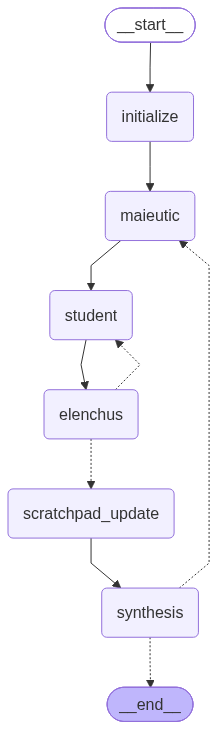

In [20]:
sdr = build_sdr_graph(slm_qwen25_3_B)
from IPython.display import Image, display

# Assuming 'app' is your compiled graph: app = workflow.compile()
display(Image(sdr.get_graph().draw_mermaid_png()))

## Section 7.6: Unified Task Factory Interface

In [21]:
# ==============================================================================
# SDR Framework - Unified Task Factory Interface
# Purpose: Provide a standardized callable execution closure for batch GSM8K
#          evaluation in Phoenix, returning extracted answers and audit traces.
# ==============================================================================

def create_SDR_task(slm):
    """
    Factory function compiling the 4-Node SDR Finite State Machine into a callable task.
    
    Args:
        slm: Instantiated LangChain SLM
    """
    sdr_framework = build_sdr_graph(slm)

    def SDR_task(problem: Dict) -> Dict:
        """Executes the SDR graph over a GSM8K input sample."""
        initial_state: SDRState = {
            "question": problem["question"],
            "scratchpad": [],
            "current_maieutic_turn": 0,
            "current_elenchus_turn": 0,
            "max_maieutic_turns": 6,
            "max_elenchus_turns": 4,
            "is_complete": False,
            "current_sub_question": None,
            "current_sub_answer": None,
            "current_student_reasoning": None,
            "elenchus_decision": None,
            "elenchus_feedback": None,
            "final_answer": None,
            "synthesis": None,
        }
        
        graph_output = sdr_framework.invoke(initial_state)
        
        return {
            "gen_answer": str(graph_output.get("final_answer", "")),
            "graph_state": graph_output
        }

    return SDR_task

# Section 8: Evaluation Metric Formulation — Exact Match (EM)

In [22]:
# ==============================================================================
# Evaluation Metric Implementation - Strict Exact Match (EM)
# Purpose: Define the binary scoring function computing Exact Match (EM) accuracy
#          between model generated answers and canonical GSM8K targets.
# ==============================================================================

def eval_exact_match(output: dict, expected: dict) -> bool:
    """
    Computes binary Exact Match (EM) between model prediction and ground truth.

    Args:
        output (dict): Model execution payload containing 'gen_answer'.
        expected (dict): Ground truth reference dictionary containing 'answer'.

    Returns:
        bool: True if prediction character-matches the cleansed reference target,
              False otherwise.
    """
    # Debug/Audit telemetry prints (retained for evaluation tracing)
    # print("Evaluator - eval_exact_match")
    # print("gen_answer: ", output.get("gen_answer"))
    # print("answer: ", expected.get("answer"))

    return output.get("gen_answer") == expected.get("answer").strip()

# Section 9: Benchmark Execution

## Section 9.1 Select Data partition

TEST RUNS ONLY: Fetch Small Evaluation Split


In [23]:
# from phoenix.client import Client

client = Client()

# This only pulls examples belonging to the specified splits
dataset = client.datasets.get_dataset(
    dataset="gsm8k_main_test",
    ######## splits=["test_20"] # Name of split # test_5, test_10, test_20, test_100
)

## Section 9.2 Qwen2.5 7B Instruct Experiment

In [29]:
SLM = slm_qwen25_7_B

### DA

In [33]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

da_task = create_da_task(slm=SLM) 
experiment = client.experiments.run_experiment( 
    experiment_name= f"DA_{SLM.model}",
    dataset=dataset,
    task=da_task,
    evaluators=[eval_exact_match],
) 

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDox


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Task runs completed.
🧠 Evaluation started.


running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Experiment completed: 300 task runs, 1 evaluator runs, 300 evaluations


### CoT

In [34]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

CoT_task = create_CoT_task(slm=SLM) 

experiment = client.experiments.run_experiment( 
    experiment_name= f"CoT_{SLM.model}",
    dataset=dataset,
    task=CoT_task,
    evaluators=[eval_exact_match]
) 

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDoy


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/langchain_core/output_parsers/pydantic.py", line 28, in _parse_obj
    return self.pydantic_object.model_validate(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pydantic/main.py", line 732, in model_validate
    return cls.__pydantic_validator__.validate_python(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
pydantic_core._pydantic_core.ValidationError: 1 validation error for CoTResponse
final_answer
  Field required [type=missing, input_value={'reasoning': 'Ram starts...ens to the 55 pens, he'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resou

running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Experiment completed: 300 task runs, 1 evaluator runs, 300 evaluations


### SDR

In [35]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

SDR_task = create_SDR_task(slm=SLM) 

experiment = client.experiments.run_experiment( 
    experiment_name= f"SDR_{SLM.model}",
    dataset=dataset,
    task=SDR_task,
    evaluators=[eval_exact_match] 
)


🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDoz


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Task runs completed.
🧠 Evaluation started.


running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Experiment completed: 300 task runs, 1 evaluator runs, 300 evaluations


## Section 9.3 Qwen2.5 3B Instruct Experiment

In [24]:
SLM = slm_qwen25_3_B

### DA

In [25]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

da_task = create_da_task(slm=SLM) 
experiment = client.experiments.run_experiment( 
    experiment_name= f"DA_{SLM.model}",
    dataset=dataset,
    task=da_task,
    evaluators=[eval_exact_match],
) 

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDo0


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Task runs completed.
🧠 Evaluation started.


running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Experiment completed: 300 task runs, 1 evaluator runs, 300 evaluations


### CoT

In [26]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

CoT_task = create_CoT_task(slm=SLM) 

experiment = client.experiments.run_experiment( 
    experiment_name= f"CoT_{SLM.model}",
    dataset=dataset,
    task=CoT_task,
    evaluators=[eval_exact_match]
) 

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDo1


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/langchain_core/output_parsers/pydantic.py", line 28, in _parse_obj
    return self.pydantic_object.model_validate(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pydantic/main.py", line 732, in model_validate
    return cls.__pydantic_validator__.validate_python(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
pydantic_core._pydantic_core.ValidationError: 1 validation error for CoTResponse
final_answer
  Field required [type=missing, input_value={'reasoning': "First, we ...r the return trip is D"}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resou

running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Experiment completed: 300 task runs, 1 evaluator runs, 300 evaluations


### SDR

In [27]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

SDR_task = create_SDR_task(slm=SLM) 

experiment = client.experiments.run_experiment( 
    experiment_name= f"SDR_{SLM.model}",
    dataset=dataset,
    task=SDR_task,
    evaluators=[eval_exact_match] 
)

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDo2


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/langchain_core/output_parsers/pydantic.py", line 28, in _parse_obj
    return self.pydantic_object.model_validate(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pydantic/main.py", line 732, in model_validate
    return cls.__pydantic_validator__.validate_python(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
pydantic_core._pydantic_core.ValidationError: 1 validation error for StudentResponse
sub_question_answer
  Field required [type=missing, input_value={'reasoning': "To find th... the remaining 6 miles"}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/c

running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resources/experiments/__init__.py", line 1997, in _run_single_evaluation_sync
    result = evaluator.evaluate(
             ^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resources/experiments/evaluators.py", line 334, in evaluate
    result = func(*bound_signature.args, **bound_signature.kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4300/3648137359.py", line 24, in eval_exact_match
    return output.get("gen_answer") == expected.get("answer").strip()
           ^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'get'

The above exception was the direct cause of the following exception:

RuntimeError: evaluator failed for example id 'RGF0YXNldEV4YW1wbGU6NjI=', repetition 1

Experiment completed: 300 task runs, 1 evaluator runs, 299 evaluat

### SDR re-run

In [28]:
# re-run failed item

ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

resumed_experiment = client.experiments.resume_experiment(
    experiment_id="RXhwZXJpbWVudDo2",
    task=SDR_task,
    evaluators=[eval_exact_match] 
)

🔍 Checking for incomplete runs...
🧪 Resuming experiment with 1 incomplete runs...
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDo2
Processing batch of 1 incomplete runs...


resuming tasks |          | 0/1 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Task runs completed.

🔍 Checking for incomplete evaluations...
🧠 Resuming evaluations...
Processing batch of 1 evaluation tasks...


running experiment evaluations |          | 0/1 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Evaluations completed.

📊 Experiment Resume Summary
Experiment ID: RXhwZXJpbWVudDo2
Incomplete runs processed: 1
Successfully completed: 1



## Section 9.4 Qwen2.5 1.5B Instruct Experiment

In [43]:
SLM = slm_qwen25_1_5_B

### DA

In [34]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

da_task = create_da_task(slm=SLM) 
experiment = client.experiments.run_experiment( 
    experiment_name= f"DA_{SLM.model}",
    dataset=dataset,
    task=da_task,
    evaluators=[eval_exact_match],
) 

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDo3


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Task runs completed.
🧠 Evaluation started.


running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Experiment completed: 300 task runs, 1 evaluator runs, 300 evaluations


### CoT

In [35]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

CoT_task = create_CoT_task(slm=SLM) 

experiment = client.experiments.run_experiment( 
    experiment_name= f"CoT_{SLM.model}",
    dataset=dataset,
    task=CoT_task,
    evaluators=[eval_exact_match]
) 

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDo4


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/langchain_core/output_parsers/pydantic.py", line 28, in _parse_obj
    return self.pydantic_object.model_validate(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pydantic/main.py", line 732, in model_validate
    return cls.__pydantic_validator__.validate_python(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
pydantic_core._pydantic_core.ValidationError: 1 validation error for CoTResponse
final_answer
  Field required [type=missing, input_value={'reasoning': 'The first ...368, which is $0.01814'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resou

running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resources/experiments/__init__.py", line 1997, in _run_single_evaluation_sync
    result = evaluator.evaluate(
             ^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resources/experiments/evaluators.py", line 334, in evaluate
    result = func(*bound_signature.args, **bound_signature.kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4300/3648137359.py", line 24, in eval_exact_match
    return output.get("gen_answer") == expected.get("answer").strip()
           ^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'get'

The above exception was the direct cause of the following exception:

RuntimeError: evaluator failed for example id 'RGF0YXNldEV4YW1wbGU6Ng==', repetition 1

Experiment completed: 300 task runs, 1 evaluator runs, 299 evaluat

### CoT re-run

In [45]:
# re-run failed item

ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

CoT_task = create_CoT_task(slm=SLM) 

resumed_experiment = client.experiments.resume_experiment(
    experiment_id="RXhwZXJpbWVudDo4",
    task=CoT_task,
    evaluators=[eval_exact_match]
)

🔍 Checking for incomplete runs...
🧪 Resuming experiment with 1 incomplete runs...
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDo4
Processing batch of 1 incomplete runs...


resuming tasks |          | 0/1 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Task runs completed.

🔍 Checking for incomplete evaluations...
🧠 Resuming evaluations...
Processing batch of 1 evaluation tasks...


running experiment evaluations |          | 0/1 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Evaluations completed.

📊 Experiment Resume Summary
Experiment ID: RXhwZXJpbWVudDo4
Incomplete runs processed: 1
Successfully completed: 1



### SDR

In [36]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

SDR_task = create_SDR_task(slm=SLM) 

experiment = client.experiments.run_experiment( 
    experiment_name= f"SDR_{SLM.model}",
    dataset=dataset,
    task=SDR_task,
    evaluators=[eval_exact_match] 
)

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDo5


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/langchain_core/output_parsers/pydantic.py", line 28, in _parse_obj
    return self.pydantic_object.model_validate(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pydantic/main.py", line 732, in model_validate
    return cls.__pydantic_validator__.validate_python(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
pydantic_core._pydantic_core.ValidationError: 1 validation error for StudentResponse
sub_question_answer
  Field required [type=missing, input_value={'reasoning': 'To find ou...ggs/4 weeks = 21 eggs/'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/c

running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resources/experiments/__init__.py", line 1997, in _run_single_evaluation_sync
    result = evaluator.evaluate(
             ^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resources/experiments/evaluators.py", line 334, in evaluate
    result = func(*bound_signature.args, **bound_signature.kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4300/3648137359.py", line 24, in eval_exact_match
    return output.get("gen_answer") == expected.get("answer").strip()
           ^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'get'

The above exception was the direct cause of the following exception:

RuntimeError: evaluator failed for example id 'RGF0YXNldEV4YW1wbGU6MjU4', repetition 1

Traceback (most recent call last):
  File "/home/zeus/miniconda3/e

### SDR re-run

In [46]:
# re-run failed item

ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

SDR_task = create_SDR_task(slm=SLM) 

resumed_experiment = client.experiments.resume_experiment(
    experiment_id="RXhwZXJpbWVudDo5",
    task=SDR_task,
    evaluators=[eval_exact_match]
)

🔍 Checking for incomplete runs...
🧪 Resuming experiment with 2 incomplete runs...
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDo5
Processing batch of 2 incomplete runs...


resuming tasks |          | 0/2 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/langchain_core/output_parsers/pydantic.py", line 28, in _parse_obj
    return self.pydantic_object.model_validate(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pydantic/main.py", line 732, in model_validate
    return cls.__pydantic_validator__.validate_python(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
pydantic_core._pydantic_core.ValidationError: 1 validation error for StudentResponse
sub_question_answer
  Field required [type=missing, input_value={'reasoning': 'To find th...st of lemons and sugar'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/c

running experiment evaluations |          | 0/1 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Evaluations completed.

📊 Experiment Resume Summary
Experiment ID: RXhwZXJpbWVudDo5
Incomplete runs processed: 2
Successfully completed: 1



## Section 9.5 Qwen2.5 0.5B Instruct Experiment

In [56]:
SLM = slm_qwen25_0_5_B

### DA

In [57]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

da_task = create_da_task(slm=SLM) 
experiment = client.experiments.run_experiment( 
    experiment_name= f"DA_{SLM.model}",
    dataset=dataset,
    task=da_task,
    evaluators=[eval_exact_match],
) 

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDoxMA==


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Task runs completed.
🧠 Evaluation started.


running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Experiment completed: 300 task runs, 1 evaluator runs, 300 evaluations


### CoT

In [58]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

CoT_task = create_CoT_task(slm=SLM) 

experiment = client.experiments.run_experiment( 
    experiment_name= f"CoT_{SLM.model}",
    dataset=dataset,
    task=CoT_task,
    evaluators=[eval_exact_match]
) 

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDoxMQ==


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/langchain_core/output_parsers/pydantic.py", line 28, in _parse_obj
    return self.pydantic_object.model_validate(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pydantic/main.py", line 732, in model_validate
    return cls.__pydantic_validator__.validate_python(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
pydantic_core._pydantic_core.ValidationError: 1 validation error for CoTResponse
final_answer
  Field required [type=missing, input_value={'reasoning': 'Gene has o...0.00000000000000619062'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resou

running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Experiment completed: 300 task runs, 1 evaluator runs, 300 evaluations


### SDR

In [59]:
ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

SDR_task = create_SDR_task(slm=SLM) 

experiment = client.experiments.run_experiment( 
    experiment_name= f"SDR_{SLM.model}",
    dataset=dataset,
    task=SDR_task,
    evaluators=[eval_exact_match] 
)

🧪 Experiment started.
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDoxMg==


running tasks |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/langchain_core/output_parsers/pydantic.py", line 28, in _parse_obj
    return self.pydantic_object.model_validate(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pydantic/main.py", line 732, in model_validate
    return cls.__pydantic_validator__.validate_python(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
pydantic_core._pydantic_core.ValidationError: 1 validation error for StudentResponse
sub_question_answer
  Field required [type=missing, input_value={'reasoning': "Suzy's iPh...4 of Suzy's age. Since"}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/c

running experiment evaluations |          | 0/300 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resources/experiments/__init__.py", line 1997, in _run_single_evaluation_sync
    result = evaluator.evaluate(
             ^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/client/resources/experiments/evaluators.py", line 334, in evaluate
    result = func(*bound_signature.args, **bound_signature.kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4300/3648137359.py", line 24, in eval_exact_match
    return output.get("gen_answer") == expected.get("answer").strip()
           ^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'get'

The above exception was the direct cause of the following exception:

RuntimeError: evaluator failed for example id 'RGF0YXNldEV4YW1wbGU6MjUy', repetition 1

Traceback (most recent call last):
  File "/home/zeus/miniconda3/e

### SDR re-run

In [63]:
# re-run failed item

ollama.chat(model=SLM.model, messages=[{"role": "user", "content": "hi"}]) 

SDR_task = create_SDR_task(slm=SLM) 

resumed_experiment = client.experiments.resume_experiment(
    experiment_id="RXhwZXJpbWVudDoxMg==",
    task=SDR_task,
    evaluators=[eval_exact_match]
)

🔍 Checking for incomplete runs...
🧪 Resuming experiment with 3 incomplete runs...
📺 View dataset experiments: http://127.0.0.1:6006/datasets/RGF0YXNldDox/experiments
🔗 View this experiment: http://127.0.0.1:6006/datasets/RGF0YXNldDox/compare?experimentId=RXhwZXJpbWVudDoxMg==
Processing batch of 3 incomplete runs...


resuming tasks |          | 0/3 (0.0%) | ⏳ 00:00<? | ?it/s

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/langchain_core/output_parsers/pydantic.py", line 28, in _parse_obj
    return self.pydantic_object.model_validate(obj)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pydantic/main.py", line 732, in model_validate
    return cls.__pydantic_validator__.validate_python(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
pydantic_core._pydantic_core.ValidationError: 1 validation error for StudentResponse
sub_question_answer
  Field required [type=missing, input_value={'reasoning': "Let's deno... The cost for sugar is"}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/phoenix/c

running experiment evaluations |          | 0/2 (0.0%) | ⏳ 00:00<? | ?it/s

✅ Evaluations completed.

📊 Experiment Resume Summary
Experiment ID: RXhwZXJpbWVudDoxMg==
Incomplete runs processed: 3
Successfully completed: 2



# Section 10 Dataset and Experiment Details

In [5]:
pd.DataFrame(client.datasets.list())

,id,name,description,metadata,created_at,updated_at,example_count
0,RGF0YXNldDox,gsm8k_main_test,dataframe.csv,{},2026-08-29T11:34:53+00:00,2026-08-29T11:34:53+00:00,300


In [6]:
pd.DataFrame(client.experiments.list(dataset_id='RGF0YXNldDox'))

,id,dataset_id,dataset_version_id,name,description,repetitions,metadata,project_name,created_at,updated_at,example_count,successful_run_count,failed_run_count,missing_run_count
0,RXhwZXJpbWVudDoxMg==,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,SDR_qwen2.5:0.5b-instruct,None,1,{},Experiment-c8d3491d86201427965696b3,2026-08-30T06:39:22+00:00,2026-08-30T06:39:22+00:00,300,299,1,0
1,RXhwZXJpbWVudDoxMQ==,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,CoT_qwen2.5:0.5b-instruct,None,1,{},Experiment-5d3106f647961e8a0e9e5269,2026-08-30T06:36:49+00:00,2026-08-30T06:36:49+00:00,300,300,0,0
2,RXhwZXJpbWVudDoxMA==,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,DA_qwen2.5:0.5b-instruct,None,1,{},Experiment-fbd9ec1340b5a4b963ece28f,2026-08-30T06:36:09+00:00,2026-08-30T06:36:09+00:00,300,300,0,0
3,RXhwZXJpbWVudDo5,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,SDR_qwen2.5:1.5b-instruct,None,1,{},Experiment-8473c5ab5d42bb06cb2f68e3,2026-08-30T05:52:31+00:00,2026-08-30T05:52:31+00:00,300,299,1,0
4,RXhwZXJpbWVudDo4,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,CoT_qwen2.5:1.5b-instruct,None,1,{},Experiment-fab98a4e8a96b0755b244b1b,2026-08-30T05:47:59+00:00,2026-08-30T05:47:59+00:00,300,300,0,0
5,RXhwZXJpbWVudDo3,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,DA_qwen2.5:1.5b-instruct,None,1,{},Experiment-94998a502628aff44915a554,2026-08-30T05:47:17+00:00,2026-08-30T05:47:17+00:00,300,300,0,0
6,RXhwZXJpbWVudDo2,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,SDR_qwen2.5:3b-instruct,None,1,{},Experiment-68c56847461b3860658d59a6,2026-08-30T04:56:17+00:00,2026-08-30T04:56:17+00:00,300,300,0,0
7,RXhwZXJpbWVudDo1,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,CoT_qwen2.5:3b-instruct,None,1,{},Experiment-a6ab0841c23251b68d7aa41f,2026-08-30T04:47:36+00:00,2026-08-30T04:47:36+00:00,300,300,0,0
8,RXhwZXJpbWVudDo0,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,DA_qwen2.5:3b-instruct,None,1,{},Experiment-00c870b1a721b3561dd86967,2026-08-30T04:46:41+00:00,2026-08-30T04:46:41+00:00,300,300,0,0
9,RXhwZXJpbWVudDoz,RGF0YXNldDox,RGF0YXNldFZlcnNpb246MQ==,SDR_qwen2.5:7b-instruct,None,1,{},Experiment-389712aa1e4486d2ecd126ad,2026-08-29T11:55:17+00:00,2026-08-29T11:55:17+00:00,300,300,0,0


# Sextion 99 COMPUTE ENVIRONMENT METADATA LOG

In [69]:
import os
import sys
import platform
import psutil
import torch
import ollama
import transformers
import langchain
import langgraph
import phoenix as px
import importlib.metadata

print("==========================================================================")
print("                        COMPUTE ENVIRONMENT METADATA LOG                  ")
print("==========================================================================")

# 1. Hardware Infrastructure
print("\n[1/4] HARDWARE & REPRODUCIBILITY ENGINE")
print(f"• Host OS Platform         : {platform.platform()}")
print(f"• CPU Microarchitecture    : {platform.processor()}")
print(f"• CPU Core Topology        : {psutil.cpu_count(logical=False)} Physical / {psutil.cpu_count(logical=True)} Logical Threads")
print(f"• Host System Memory (RAM) : {psutil.virtual_memory().total / (1024**3):.2f} GB")

if torch.cuda.is_available():
    prop = torch.cuda.get_device_properties(0)
    print(f"• Accelerating Hardware    : {torch.cuda.get_device_name(0)}")
    print(f"• VRAM Capacity Total      : {prop.total_memory / (1024**3):.2f} GB")
    print(f"• CUDA Compute Capability  : {prop.major}.{prop.minor}")
    print(f"• CUDA Runtime Version     : {torch.version.cuda}")
    print(f"• cuDNN Library Version    : {torch.backends.cudnn.version()}")
    print(f"• Deterministic Alg Flags  : torch.use_deterministic_algorithms={torch.are_deterministic_algorithms_enabled()}")
    print(f"• cuDNN Dynamic Benchmark  : torch.backends.cudnn.benchmark={torch.backends.cudnn.benchmark}")
else:
    print("• Accelerating Hardware    : NO CUDA-COMPATIBLE DEVICE FOUND")

# 2. Local Inference Runtime Engine (Ollama Stack)
print("\n[2/4] LOCAL INFERENCE RUNTIME (OLLAMA)")
try:
    models_res = ollama.list()
    models_list = models_res.model_dump().get('models', [])
    print(f"• Active Local Models      : {[m['model'] for m in models_list]}")
    for m in models_list:
        details = m.get('details', {})
        print(f"  └─ {m['model']}: Quant={details.get('quantization_level', 'Unknown')} | Family={details.get('family', 'Unknown')} | Format={details.get('format', 'Unknown')}")
except Exception as e:
    print(f"• Ollama Daemon Status     : Query failed ({e})")

# 3. Observability, Graph, and Framework Orchestration
print("\n[3/4] SYSTEM ORCHESTRATION & OBSERVABILITY STACK")

def get_pkg_version(package_name: str) -> str:
    """Safely extracts installed package version for scientific reporting."""
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return "Not Installed"

print(f"• LangGraph Framework Ver  : {get_pkg_version('langgraph')}")
print(f"• LangChain Framework Ver  : {get_pkg_version('langchain')}")
print(f"• Transformers Framework   : {get_pkg_version('transformers')}")
print(f"• Arize Phoenix Server Ver : {get_pkg_version('arize-phoenix')}")
print(f"• Telemetry Storage Path   : {os.environ.get('PHOENIX_WORKING_DIR', 'Default Temporal')}")

print("==========================================================================")


                        COMPUTE ENVIRONMENT METADATA LOG                  

[1/4] HARDWARE & REPRODUCIBILITY ENGINE
• Host OS Platform         : Linux-6.8.0-1066-gcp-x86_64-with-glibc2.39
• CPU Microarchitecture    : x86_64
• CPU Core Topology        : 4 Physical / 8 Logical Threads
• Host System Memory (RAM) : 31.34 GB
• Accelerating Hardware    : NVIDIA L4
• VRAM Capacity Total      : 22.03 GB
• CUDA Compute Capability  : 8.9
• CUDA Runtime Version     : 13.0
• cuDNN Library Version    : 92000
• Deterministic Alg Flags  : torch.use_deterministic_algorithms=False
• cuDNN Dynamic Benchmark  : torch.backends.cudnn.benchmark=False

[2/4] LOCAL INFERENCE RUNTIME (OLLAMA)
• Active Local Models      : ['qwen2.5:7b-instruct', 'qwen2.5:3b-instruct', 'qwen2.5:1.5b-instruct', 'qwen2.5:0.5b-instruct']
  └─ qwen2.5:7b-instruct: Quant=Q4_K_M | Family=qwen2 | Format=gguf
  └─ qwen2.5:3b-instruct: Quant=Q4_K_M | Family=qwen2 | Format=gguf
  └─ qwen2.5:1.5b-instruct: Quant=Q4_K_M | Family=qwen2 | For